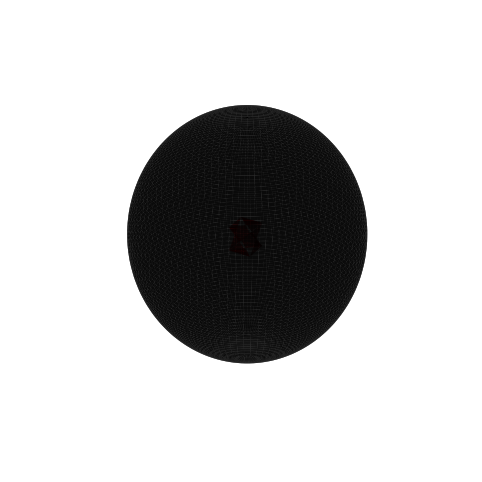

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the phi and theta ranges
phi_min, phi_max = 0*np.pi, 0*np.pi # Phi range in radians
theta_min, theta_max =0*np.pi, 0*np.pi # Theta range in radians

# Create a mesh grid for phi and theta
phi = np.linspace(0, 2 * np.pi, 100)
theta = np.linspace(0, np.pi, 100)
phi, theta = np.meshgrid(phi, theta)

# Convert spherical to Cartesian coordinates
r = 1  # Radius of the sphere
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

# Create a mask for the specified range
mask = (phi >= phi_min) & (phi <= phi_max) & (theta >= theta_min) & (theta <= theta_max)

# Plot the spherical coordinate system
fig = plt.figure()
fig.set_size_inches(8, 6)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, facecolors=np.where(mask, 'white', 'black'), rstride=1, cstride=1, linewidth=0, antialiased=True, edgecolor='none', alpha=0.8)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1
ax.set_axis_off()

# Define the size of the cube
cube_size = 0.2
shift = np.array([0, -0.3, 0])

# Define the vertices of the cube
cube_vertices = np.array([[0, 0, 0],
                          [cube_size, 0, 0],
                          [cube_size, cube_size, 0],
                          [0, cube_size, 0],
                          [0, 0, cube_size],
                          [cube_size, 0, cube_size],
                          [cube_size, cube_size, cube_size],
                          [0, cube_size, cube_size]]) + shift

# Define the faces of the cube
cube_faces = [[cube_vertices[j] for j in [0, 1, 2, 3]],
              [cube_vertices[j] for j in [4, 5, 6, 7]],
              [cube_vertices[j] for j in [0, 1, 5, 4]],
              [cube_vertices[j] for j in [2, 3, 7, 6]],
              [cube_vertices[j] for j in [1, 2, 6, 5]],
              [cube_vertices[j] for j in [4, 7, 3, 0]]]

# Plot the cube
for face in cube_faces:
    ax.plot_surface(np.array([vertex[0] for vertex in face]).reshape(2, 2),
                    np.array([vertex[1] for vertex in face]).reshape(2, 2),
                    np.array([vertex[2] for vertex in face]).reshape(2, 2),
                    color='red', edgecolor='none', alpha=0.7)

# Set the aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])  # Aspect ratio is 1:1:1

plt.show()

In [1]:
import argparse
import os
import pickle

from matplotlib import pyplot as plt

log_dir = '../logs'
plot_dir = '../plots'

distortion_types = ['gaussian_noise', 'shot_noise', 'impulse_noise', 'speckle_noise',
                    'gaussian_blur', 'glass_blur', 'defocus_blur', 'motion_blur', 'zoom_blur',
                    'fog', 'frost', 'snow', 'spatter', 'contrast', 'brightness', 'saturate',
                    'jpeg_compression', 'pixelate', 'elastic_transform',]
model_folders = ['combined_f_combined', 'combined_r_combined', 'combined_fx_combined',]

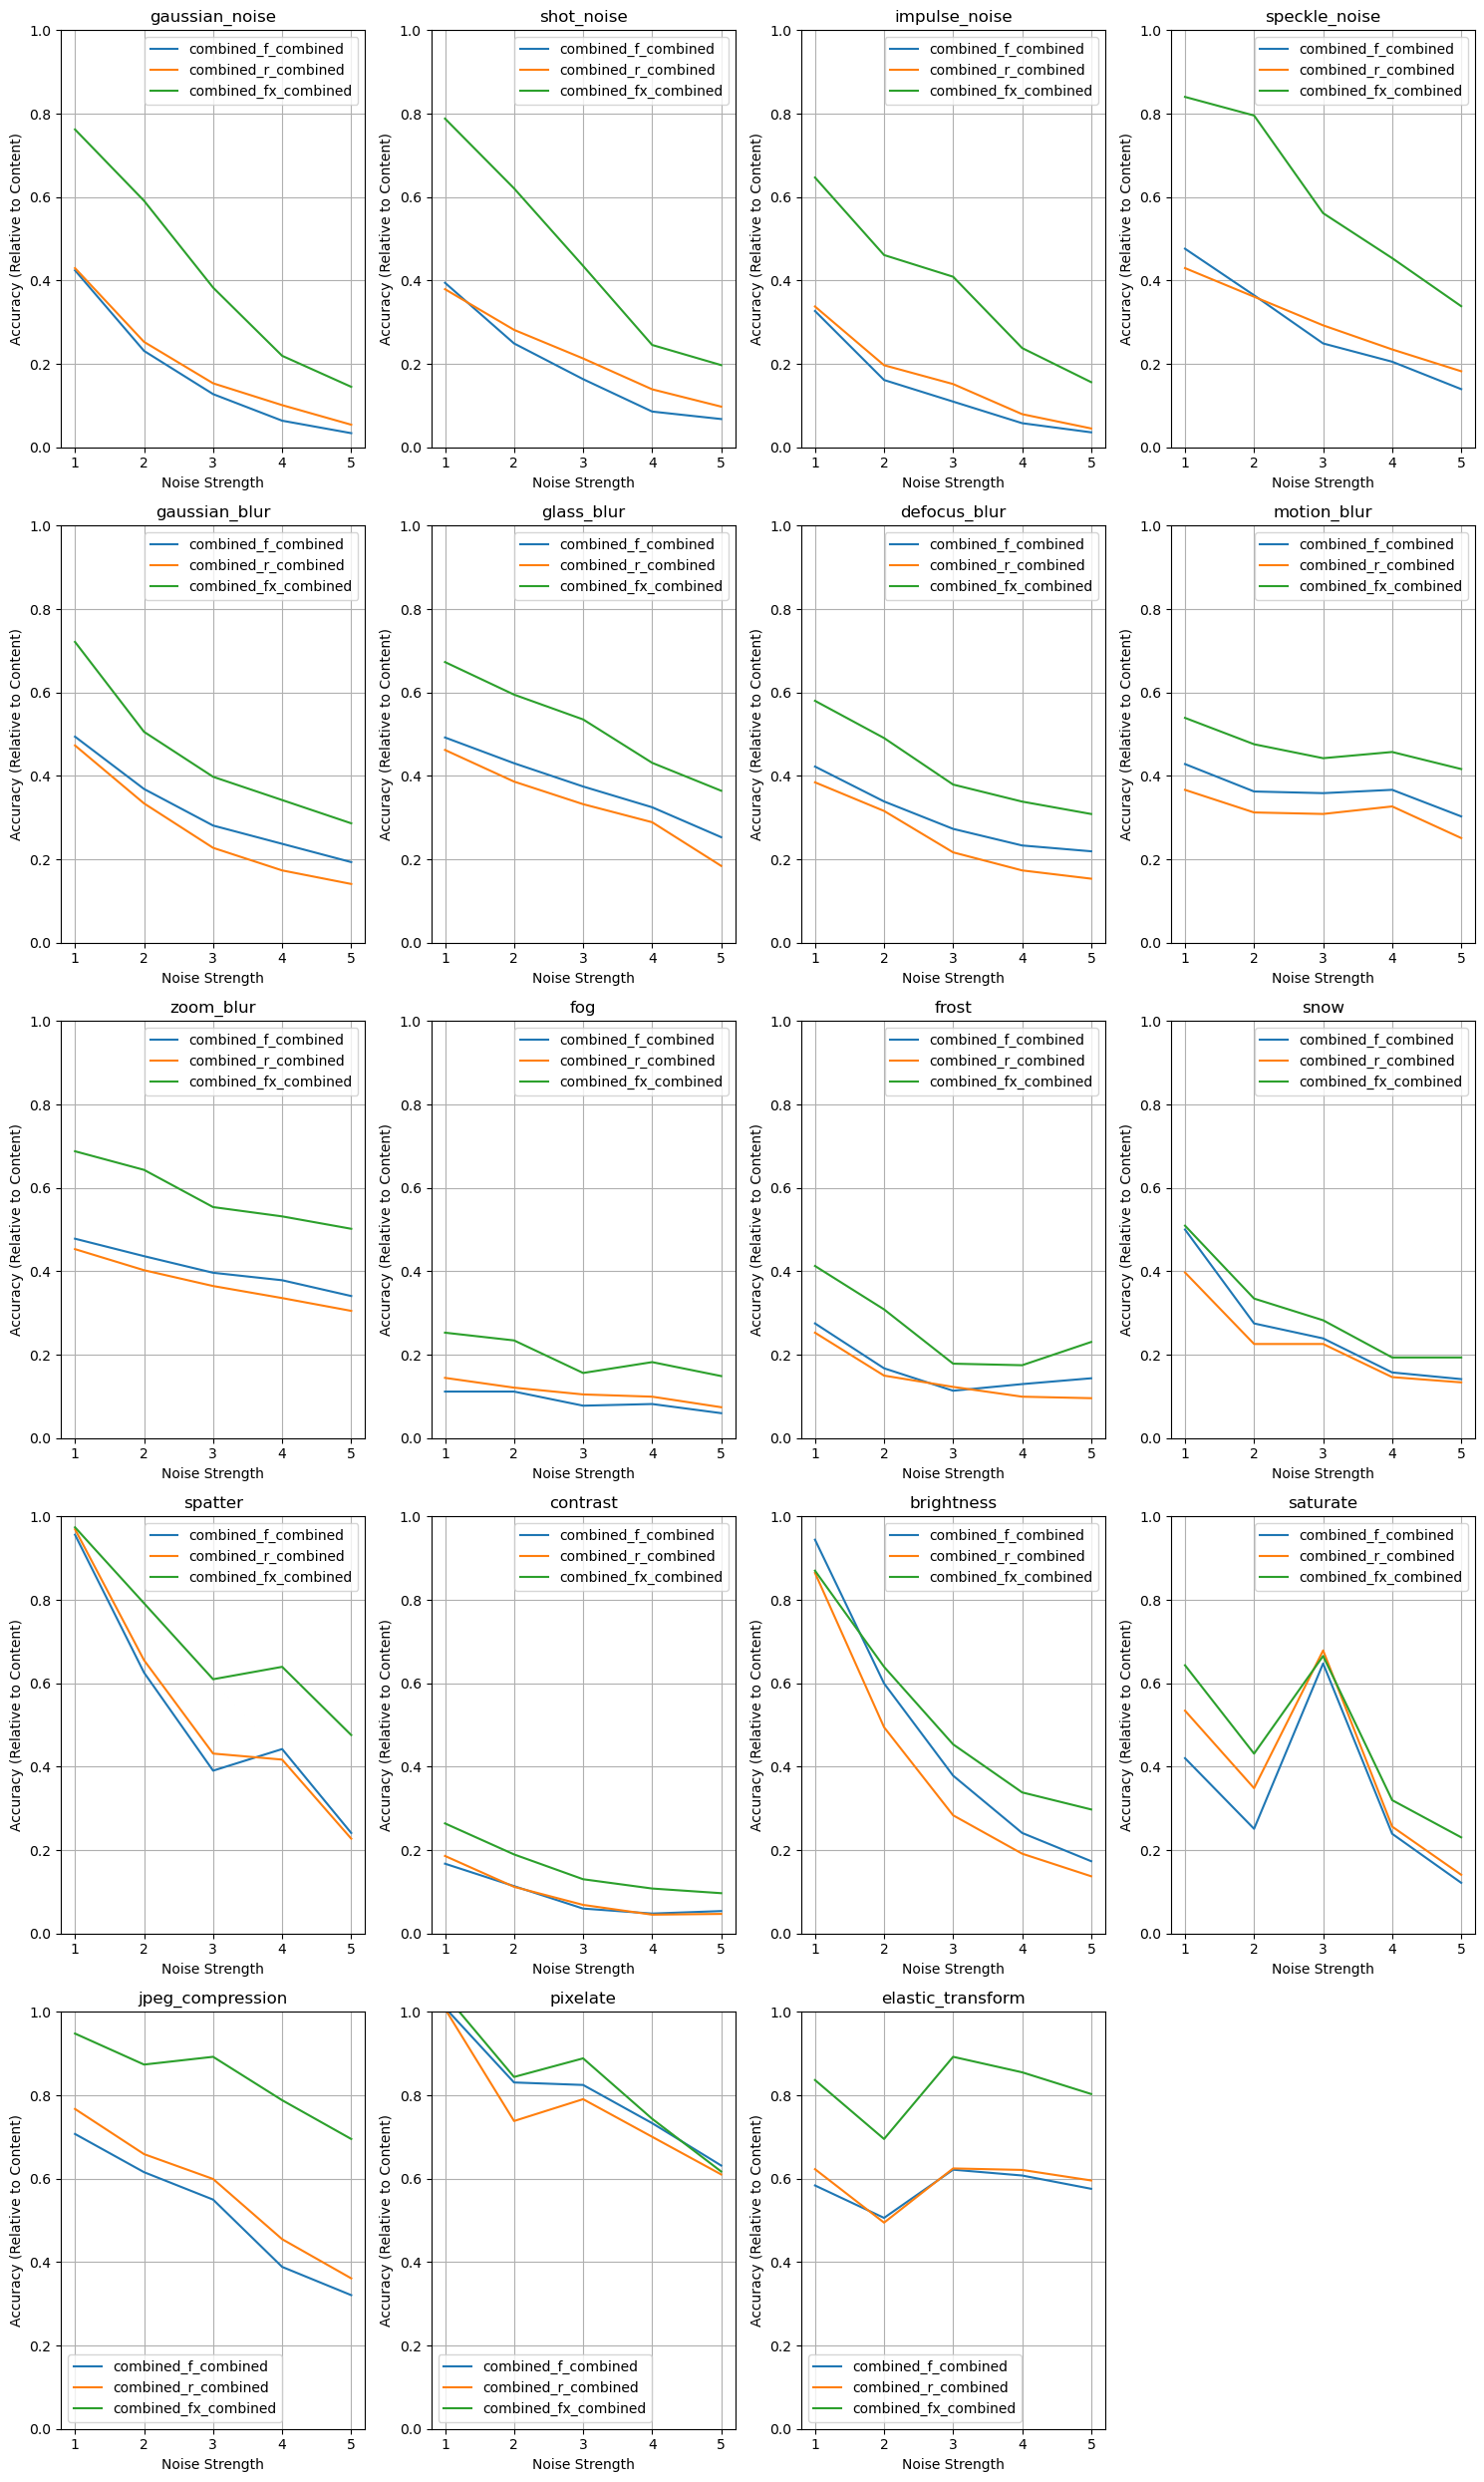

<Figure size 640x480 with 0 Axes>

In [11]:
epochs = range(30, 31)
severities = range(1, 6)

# Define the number of rows and columns based on the number of distortion types
num_distortions = len(distortion_types)
num_rows = (num_distortions + 3) // 4  # Adjust this based on how many columns you want
num_cols = min(4, num_distortions)  # Max 4 columns for a cleaner look

for epoch in epochs:
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))  # Adjust size as needed
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    # Iterate over distortion types and plot for each one
    for idx, distortion_type in enumerate(distortion_types):
        ax = axes[idx]  # Select the current subplot axis

        # For each model folder, plot the relative accuracy
        for model_folder in model_folders:
            if model_folder == 'combined_f_combined':
                viewpoint = 'r'
            elif model_folder == 'combined_r_combined':
                viewpoint = 'r'
            elif model_folder == 'combined_fx_combined':
                viewpoint = 'r'
            log_model_epoch_folder = os.path.join(log_dir, model_folder, 'robustness', str(epoch), viewpoint)
            content_acc_path = os.path.join(log_model_epoch_folder, 'content_acc.pkl')
            with open(content_acc_path, 'rb') as f:
                content_acc = pickle.load(f)

            distortion_acc_path = os.path.join(log_model_epoch_folder, 'distortion_acc.pkl')
            with open(distortion_acc_path, 'rb') as f:
                distortion_acc = pickle.load(f)

            # Retrieve content accuracy for the epoch
            content_acc_epoch = content_acc[str(epoch)]

            # Prepare to plot results for the current distortion type
            relative_accuracies = []
            for severity in severities:
                # Get distortion accuracy for each severity level
                distortion_acc_value = distortion_acc[str(epoch)][distortion_type][str(severity)]

                # Compute relative accuracy (distortion accuracy relative to content accuracy)
                relative_acc = distortion_acc_value / content_acc_epoch
                relative_accuracies.append(relative_acc)

            # Plot the relative accuracy for the current model folder on the same axis
            ax.plot(severities, relative_accuracies, label=model_folder)

        # Customize the current subplot
        ax.set_title(distortion_type)
        ax.set_xlabel('Noise Strength')
        ax.set_ylabel('Accuracy (Relative to Content)')
        ax.set_ylim(0, 1)
        ax.grid(True)
        ax.legend()

    # Remove any unused subplots (if distortion types < num_rows * num_cols)
    for i in range(num_distortions, len(axes)):
        fig.delaxes(axes[i])

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Save the combined plot
    plot_save_folder = os.path.join(plot_dir, 'robustness')
    os.makedirs(plot_save_folder, exist_ok=True)
    plot_save_path = os.path.join(plot_save_folder, f'relative_accuracy_epoch_{epoch}.png')
    plt.savefig(plot_save_path)

    # Show the plot (if running in an interactive environment)
    plt.show()  # Uncomment this if you want to see the plot in an interactive environment

    # Clear the figure for the next plot
    plt.clf()

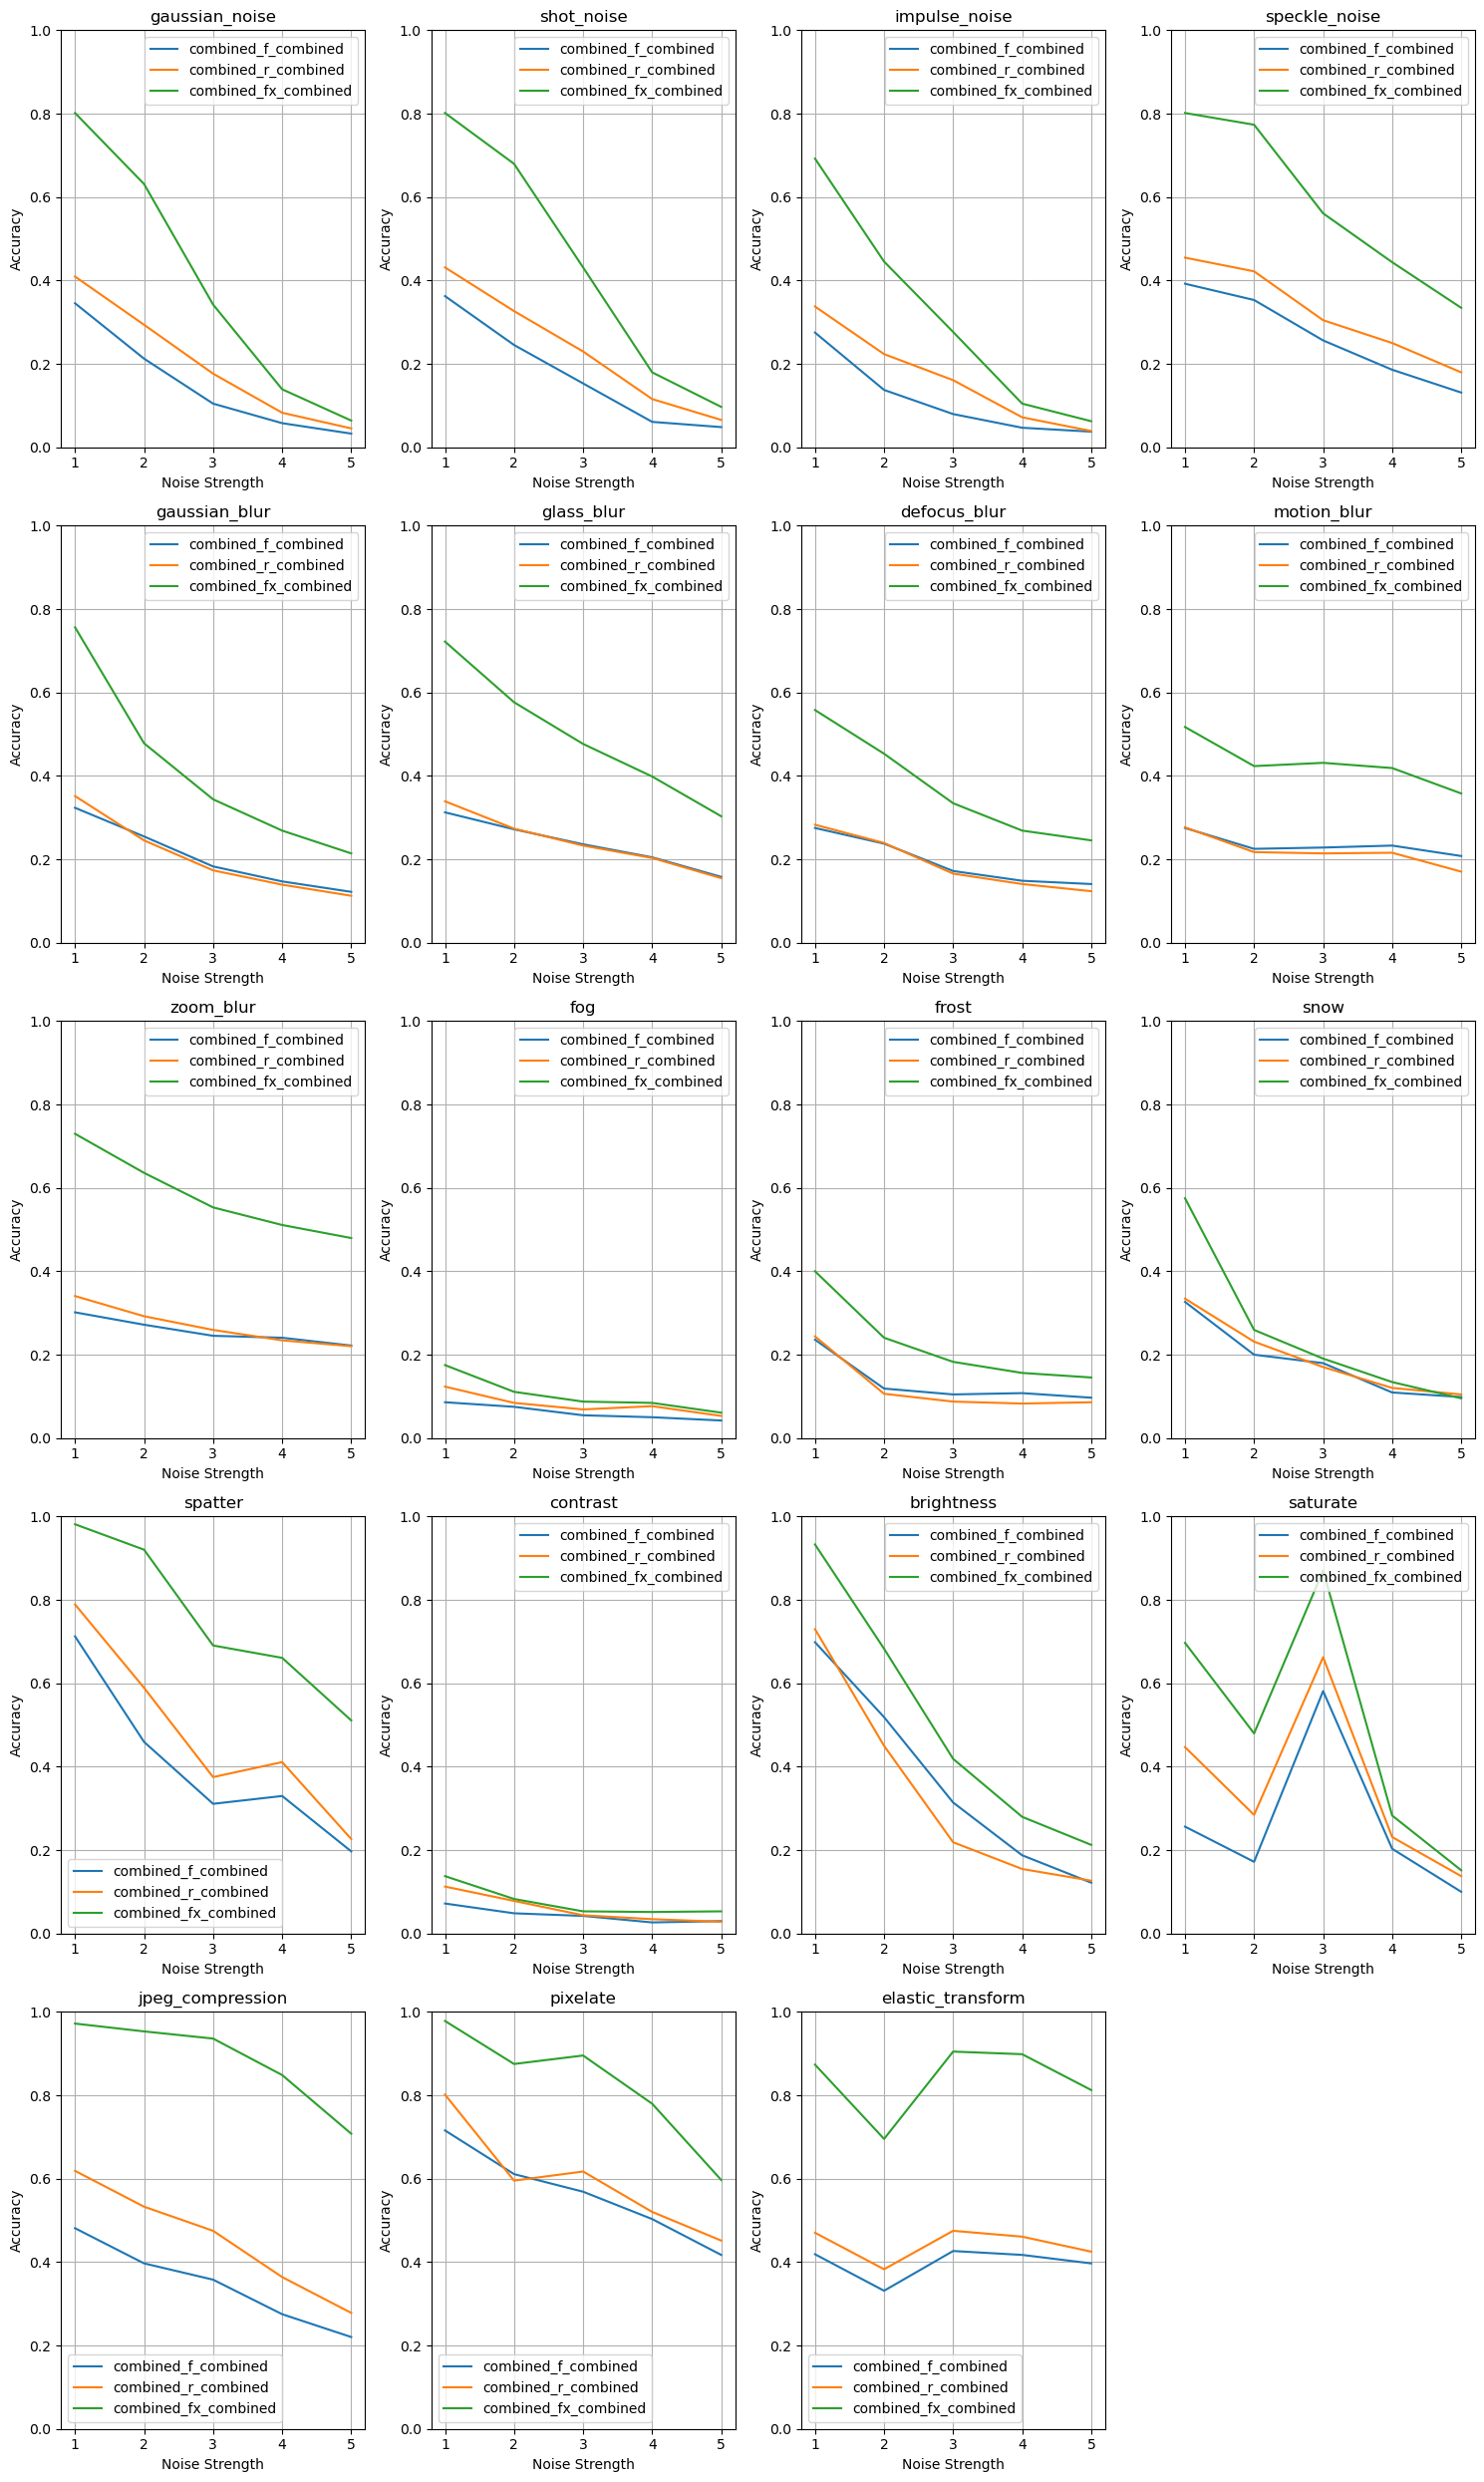

<Figure size 640x480 with 0 Axes>

In [4]:
epochs = range(30, 31)
severities = range(1, 6)

# Define the number of rows and columns based on the number of distortion types
num_distortions = len(distortion_types)
num_rows = (num_distortions + 3) // 4  # Adjust this based on how many columns you want
num_cols = min(4, num_distortions)  # Max 4 columns for a cleaner look

for epoch in epochs:
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))  # Adjust size as needed
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    # Iterate over distortion types and plot for each one
    for idx, distortion_type in enumerate(distortion_types):
        ax = axes[idx]  # Select the current subplot axis

        # For each model folder, plot the relative accuracy
        for model_folder in model_folders:
            if model_folder == 'combined_f_combined':
                viewpoint = 'fx'
            elif model_folder == 'combined_r_combined':
                viewpoint = 'fx'
            elif model_folder == 'combined_fx_combined':
                viewpoint = 'fx'
            log_model_epoch_folder = os.path.join(log_dir, model_folder, 'robustness', str(epoch), viewpoint)
            content_acc_path = os.path.join(log_model_epoch_folder, 'content_acc.pkl')
            with open(content_acc_path, 'rb') as f:
                content_acc = pickle.load(f)

            distortion_acc_path = os.path.join(log_model_epoch_folder, 'distortion_acc.pkl')
            with open(distortion_acc_path, 'rb') as f:
                distortion_acc = pickle.load(f)

            # Retrieve content accuracy for the epoch
            content_acc_epoch = content_acc[str(epoch)]

            # Prepare to plot results for the current distortion type
            distortion_acc_values = []
            for severity in severities:
                # Get distortion accuracy for each severity level
                distortion_acc_value = distortion_acc[str(epoch)][distortion_type][str(severity)]
                distortion_acc_values.append(distortion_acc_value)

            # Plot the relative accuracy for the current model folder on the same axis
            ax.plot(severities, distortion_acc_values, label=model_folder)

        # Customize the current subplot
        ax.set_title(distortion_type)
        ax.set_xlabel('Noise Strength')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1)
        ax.grid(True)
        ax.legend()

    # Remove any unused subplots (if distortion types < num_rows * num_cols)
    for i in range(num_distortions, len(axes)):
        fig.delaxes(axes[i])

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Save the combined plot
    plot_save_folder = os.path.join(plot_dir, 'robustness')
    os.makedirs(plot_save_folder, exist_ok=True)
    plot_save_path = os.path.join(plot_save_folder, f'accuracy_epoch_{epoch}.png')
    plt.savefig(plot_save_path)

    # Show the plot (if running in an interactive environment)
    plt.show()  # Uncomment this if you want to see the plot in an interactive environment

    # Clear the figure for the next plot
    plt.clf()